Dataset Shape: (805549, 9)

RFM Table Shape: (5878, 3)

RFM Summary Statistics:
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289384    3018.616737
std     209.338707    13.009406   14737.731040
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     348.762500
50%      96.000000     3.000000     898.915000
75%     380.000000     7.000000    2307.090000
max     739.000000   398.000000  608821.650000


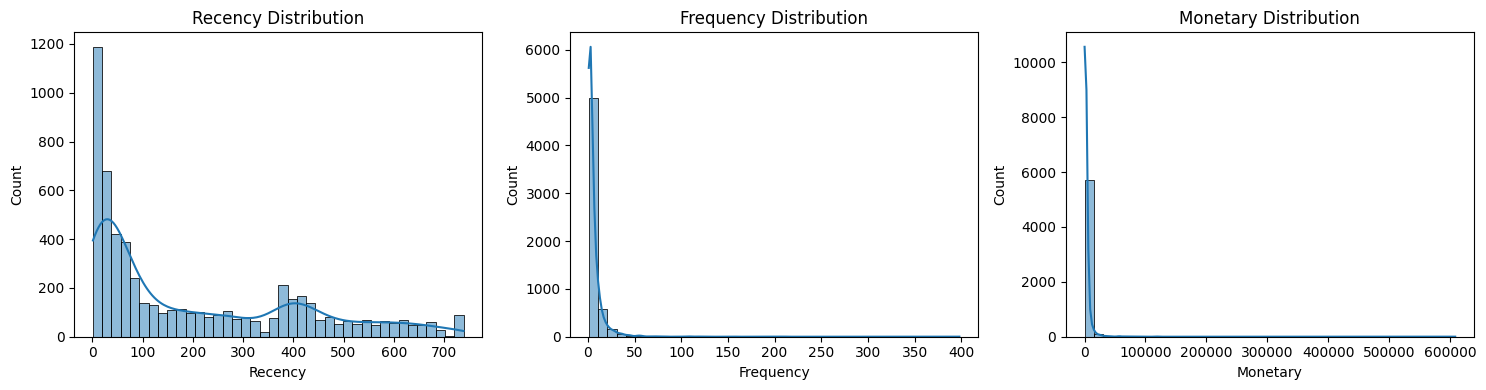


After Outlier Removal Shape: (5819, 3)


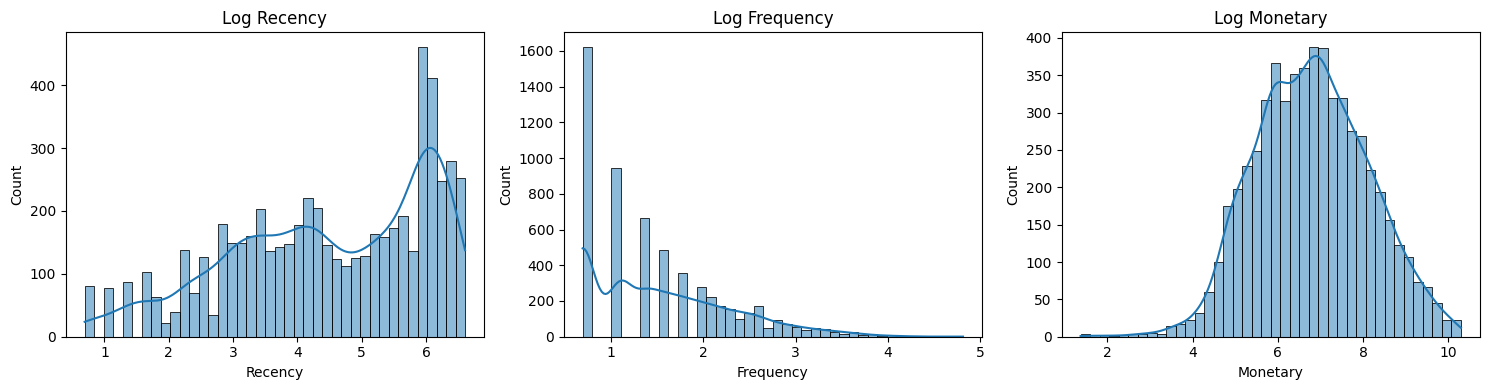


Feature Engineering Completed Successfully.


In [1]:
# ==========================================
# FEATURE ENGINEERING — RFM CREATION
# ==========================================

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 2. Load Cleaned Data
# -------------------------------
df = pd.read_csv("../data/processed/cleaned_data.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Dataset Shape:", df.shape)
df.head()

# ==========================================
# 3. CREATE RFM FEATURES
# ==========================================

# Define snapshot date (one day after last transaction)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                        # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("\nRFM Table Shape:", rfm.shape)
rfm.head()

# ==========================================
# 4. BASIC RFM ANALYSIS
# ==========================================

print("\nRFM Summary Statistics:")
print(rfm.describe())

# Visualize distributions
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=40, kde=True)
plt.title("Recency Distribution")

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=40, kde=True)
plt.title("Frequency Distribution")

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=40, kde=True)
plt.title("Monetary Distribution")

plt.tight_layout()
plt.show()

# ==========================================
# 5. REMOVE EXTREME OUTLIERS
# ==========================================

# Remove customers with zero or negative spending
rfm = rfm[rfm['Monetary'] > 0]

# Remove extreme top 1% spenders (optional but recommended)
rfm = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)]

print("\nAfter Outlier Removal Shape:", rfm.shape)

# ==========================================
# 6. LOG TRANSFORMATION (IMPORTANT FOR CLUSTERING)
# ==========================================

rfm_log = np.log1p(rfm)

# Check transformed data
rfm_log.head()

# Visualize transformed distributions
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(rfm_log['Recency'], bins=40, kde=True)
plt.title("Log Recency")

plt.subplot(1,3,2)
sns.histplot(rfm_log['Frequency'], bins=40, kde=True)
plt.title("Log Frequency")

plt.subplot(1,3,3)
sns.histplot(rfm_log['Monetary'], bins=40, kde=True)
plt.title("Log Monetary")

plt.tight_layout()
plt.show()

# ==========================================
# 7. ADDITIONAL BEHAVIORAL FEATURES (BONUS FOR HIGH MARKS)
# ==========================================

# Average Order Value
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Reapply log transform to updated features
rfm_log = np.log1p(rfm)

# ==========================================
# 8. SAVE FEATURE ENGINEERED DATA
# ==========================================

rfm_log.to_csv("../data/processed/rfm_data.csv")

print("\nFeature Engineering Completed Successfully.")